In [440]:
%run "/home/nichettg/Ubuntu/Laboratorio/moduli.py"

In [441]:
titolo = "Esperienza"
xlabel = "x"
ylabel = "y"

file_input = "dati.csv"
file_output1 = "Analisi/regressione.txt"
file_output2 = "Analisi/residui.txt"
file_output3 = "Analisi/chi.txt"
grafico_output1 = "Analisi/regressione.pdf"
grafico_output2 = "Analisi/residui.pdf"
grafico_output3 = "Analisi/chi.pdf"

### 1. Lettura

In [442]:
data = f.csv_to_dict(file_input)

incertezza_tempo = 10 * 10**(-7)
incertezza_voltaggio = 2

xdata = np.array([data["tempo"],
                  np.full_like(data["tempo"], incertezza_tempo)])
ydata = np.array([data["voltaggio"],
                  np.full_like(data["voltaggio"], incertezza_voltaggio) + 3/100 * data["voltaggio"]])

### 2. Analisi

In [443]:
def modello(par, x):
    a,b,c,d,g = par
    return a/b * np.exp(- ( x - c ) / d ) * ( 1/d * np.sin(b * (x - c ) ) + b * np.cos(b * (x - c ) ) ) + g

v0 = 45
omega0 = 4.68 * 10**(5)
t0 = 0.001
tau0 = 10**(-5)
voff = 0.01

param_labels = ['v0','omega','t0','tau','voff']
dati_iniziali = [v0,omega0,t0,tau0,voff]

Regressione

In [444]:
anal = f.fit(xdata,ydata,modello,dati_iniziali,chi=False)

f.inizializza_output(file_output1)
gf.salva_analisi(anal, param_labels, file_output1)

Residui e Chi Quadro della Regressione

In [445]:
f.inizializza_output(file_output2)
res = f.residui(xdata,ydata,anal[:,0],modello,file_output2,titolo)

f.inizializza_output(file_output3)
chi = f.chi_quadro(xdata,ydata,anal[:,0],modello,file_output3,titolo)

Andamento Chi Quadro al Variare di Omega e Tau

In [446]:
def chi_quadro(xdata,ydata,par,modello):
    somma = 0.
    vx, vsx = xdata
    vy, vsy = ydata
    for i,(x,y) in enumerate(zip(vx,vy)):
        y_star = modello(par,x)
        chi = ((y-y_star)/vsy[i])**2
        somma += chi
    return somma

In [468]:
omega = anal[1][0]
tau = anal[3][0]
zoom = 1.5
risoluzione = 30
omega = np.linspace(omega - zoom/100 * omega, omega + zoom/100 * omega, risoluzione)
tau = np.linspace(tau - zoom/100 * tau, tau + zoom/100 * tau, risoluzione)

O, T = np.meshgrid(omega, tau)

chi_quadri = np.zeros_like(O)

for i in range(O.shape[0]):
    for j in range(O.shape[1]):
        parametri = [anal[0][0], O[i, j], anal[2][0], T[i, j], anal[4][0]]
        chi_quadri[i, j] = chi_quadro(xdata, ydata, parametri, modello)

### 3. Grafici

Regressione

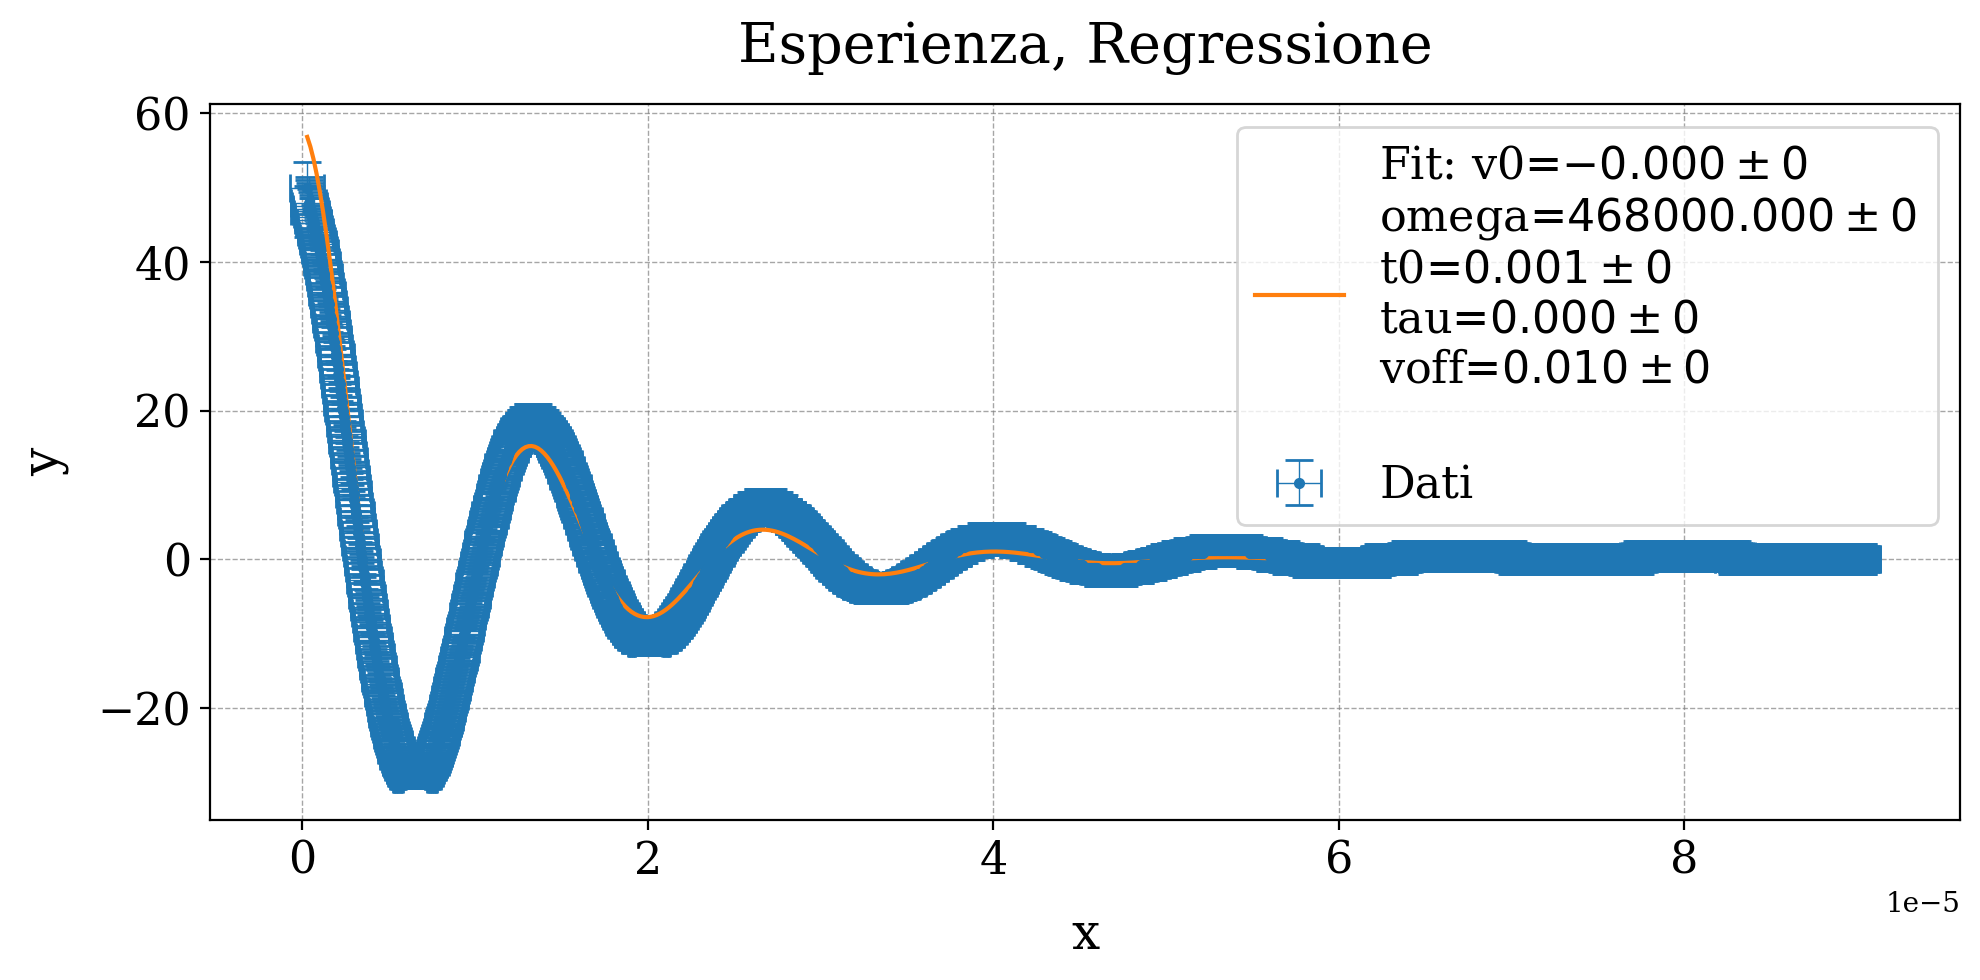

In [469]:
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + ", Regressione",xlabel=xlabel,ylabel=ylabel)
# Grafico dei dati con errori
ax.errorbar(xdata[0],ydata[0],xerr=xdata[1],yerr=ydata[1],
            label="Dati", **gf.errorbar_params, color = gf.colori[0])
# Grafico del fit
fit_label = "Fit: " + "".join(
    f"{param_labels[i]}={gf.formatta_errore(anal[i,0],anal[i,1])}\n" for i in range(len(param_labels))
)
x_fit = np.linspace(min(xdata[0]), max(xdata[0]), 500)
ax.plot(x_fit,modello(anal[:,0],x_fit),
        label=fit_label, **gf.plot_params, color = gf.colori[1])

ax.legend()

gf.salva_grafico(fig,grafico_output1)

Residui e Chi Quadro Regressione

<>:14: SyntaxWarning: invalid escape sequence '\c'
<>:14: SyntaxWarning: invalid escape sequence '\c'
/tmp/ipykernel_7886/4050647445.py:14: SyntaxWarning: invalid escape sequence '\c'
  gf.parametri_grafico(ax,titolo + r", $\chi^2$",xlabel=xlabel,ylabel="$\chi^2$")


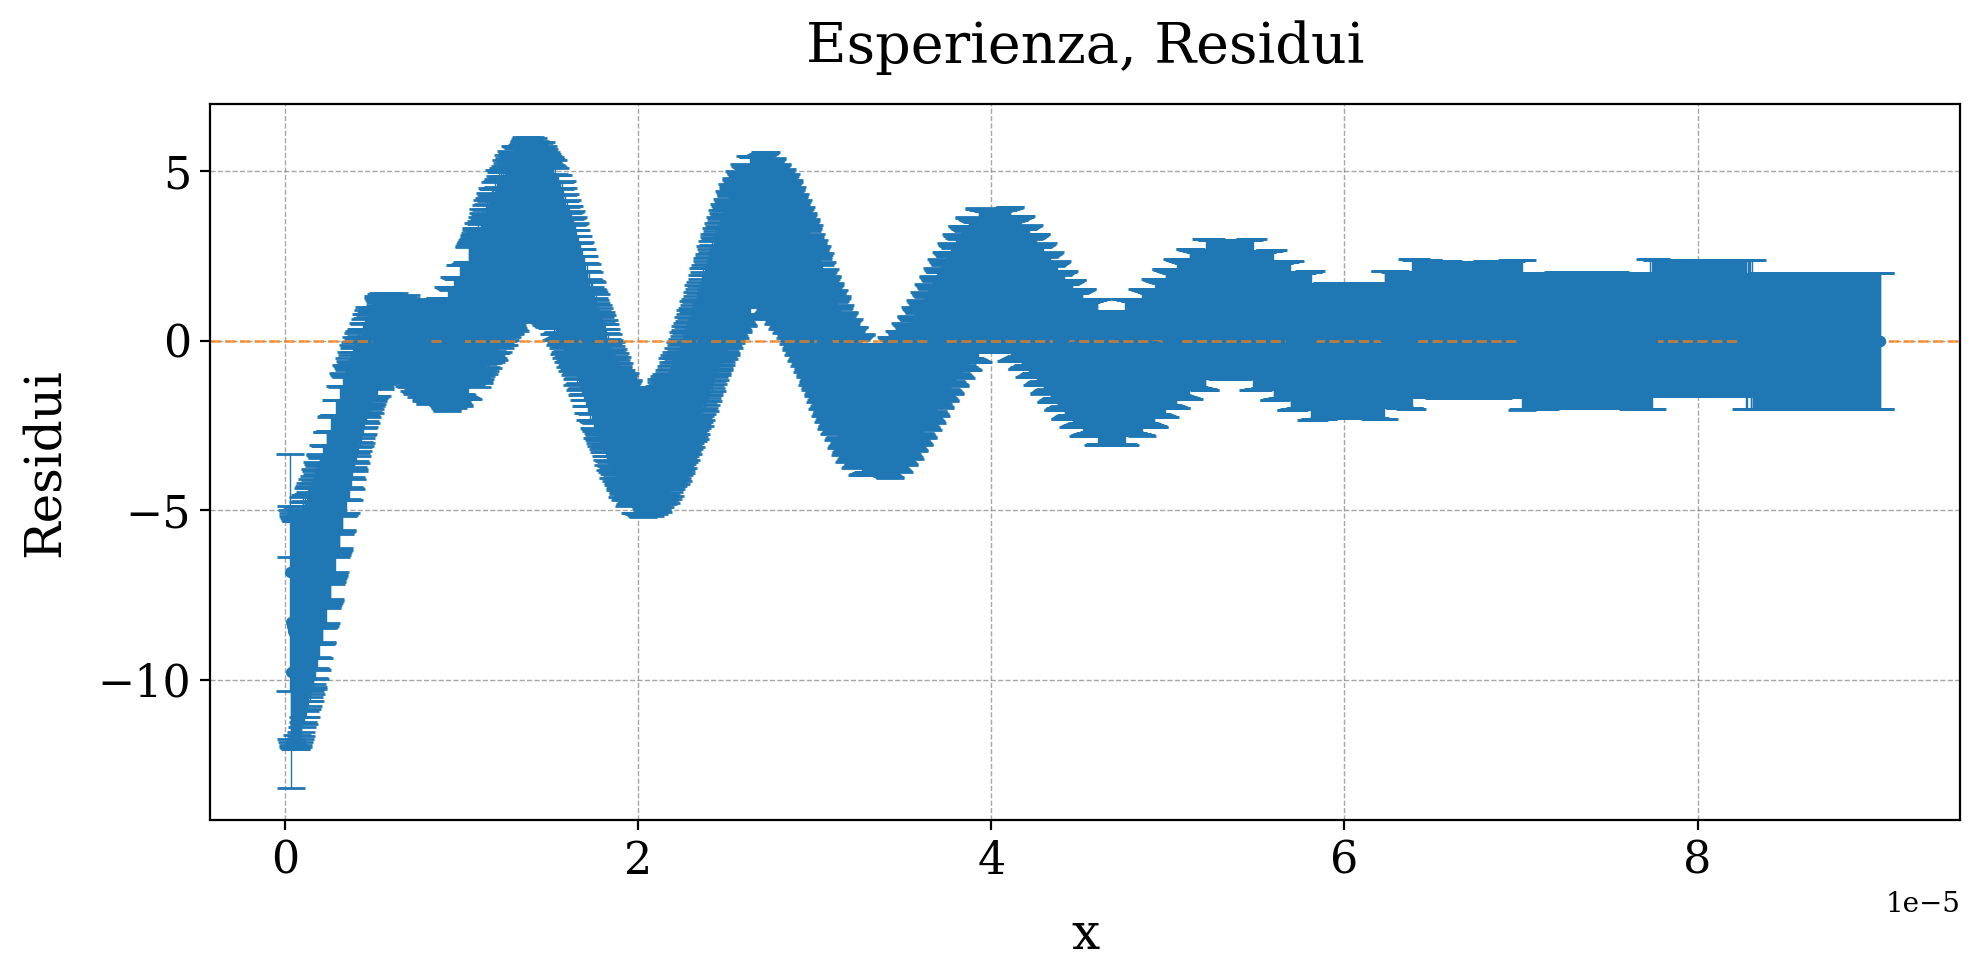

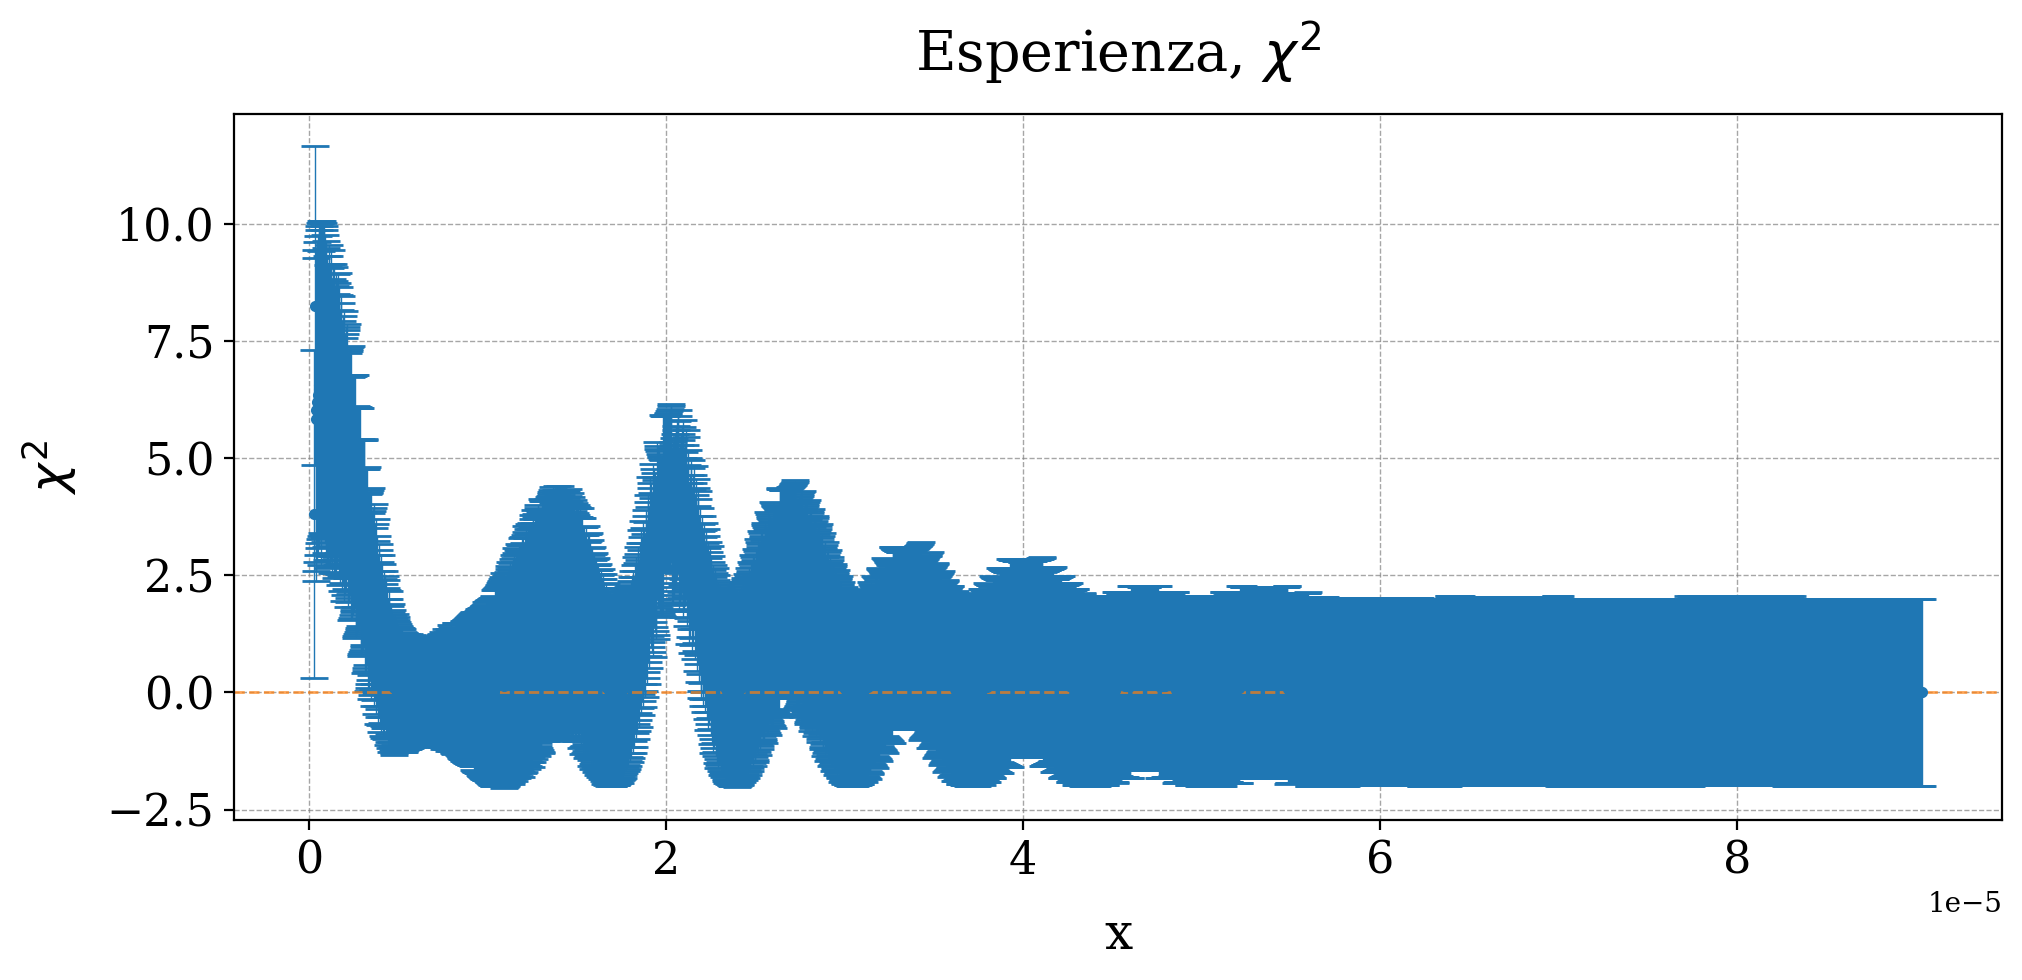

In [470]:
# Grafico dei residui
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + ", Residui",xlabel=xlabel,ylabel="Residui")

ax.errorbar(res[0],res[1],yerr=res[2],
            **gf.errorbar_params, color=gf.colori[0])
ax.axhline(0,
           **gf.line_params, color=gf.colori[1])

gf.salva_grafico(fig,grafico_output2)

# Grafico chi quadro
fig,ax = plt.subplots(1, 1,  figsize=(10, 5))
gf.parametri_grafico(ax,titolo + r", $\chi^2$",xlabel=xlabel,ylabel="$\chi^2$")

ax.errorbar(chi[0],chi[1],yerr=chi[2],
            **gf.errorbar_params, color=gf.colori[0])
ax.axhline(0,
           **gf.line_params, color=gf.colori[1])

gf.salva_grafico(fig,grafico_output3)

Andamento Chi Quadro al Variare di Omega e Tau

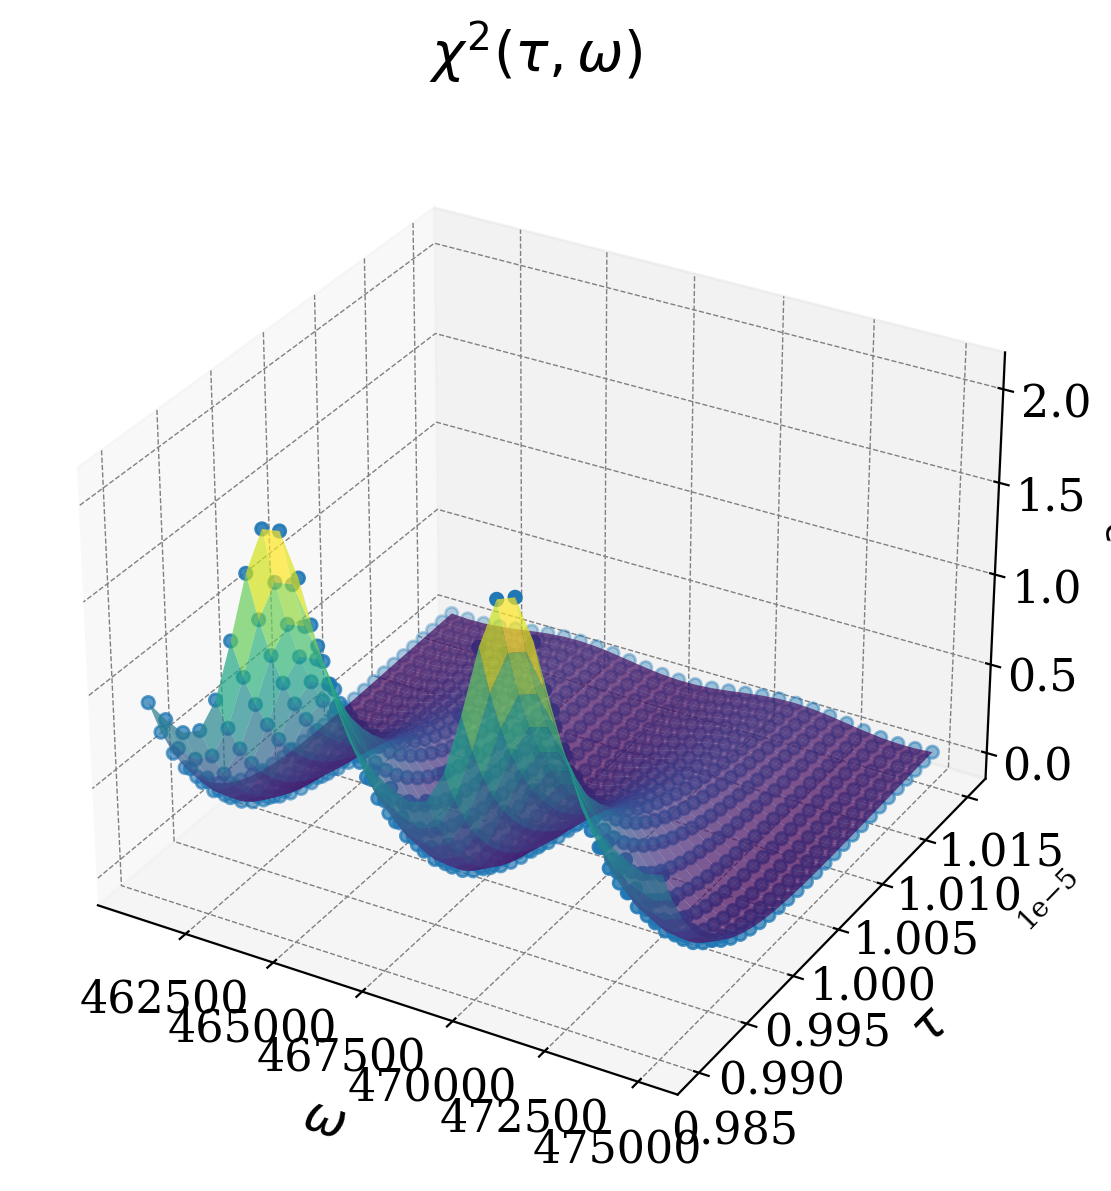

In [471]:
fig = plt.figure()
ax = fig.add_subplot(projection='3d')
gf.parametri_grafico(ax,r"$\chi^2 ( \tau,\omega )$",xlabel=r"$\omega$",ylabel=r"$\tau$",zlabel=r"$\chi^2$",tridimensionale=True)

ax.scatter(O, T, chi_quadri)
ax.plot_surface(O, T, chi_quadri, cmap='viridis', alpha=0.7)

gf.salva_grafico(fig,"chi_3d.pdf")

/tmp/ipykernel_7886/3073213117.py:4: MatplotlibDeprecationWarning: Auto-removal of grids by pcolor() and pcolormesh() is deprecated since 3.5 and will be removed two minor releases later; please call grid(False) first.
  colore = ax.pcolormesh(O, T, chi_quadri, shading='auto', cmap='viridis')


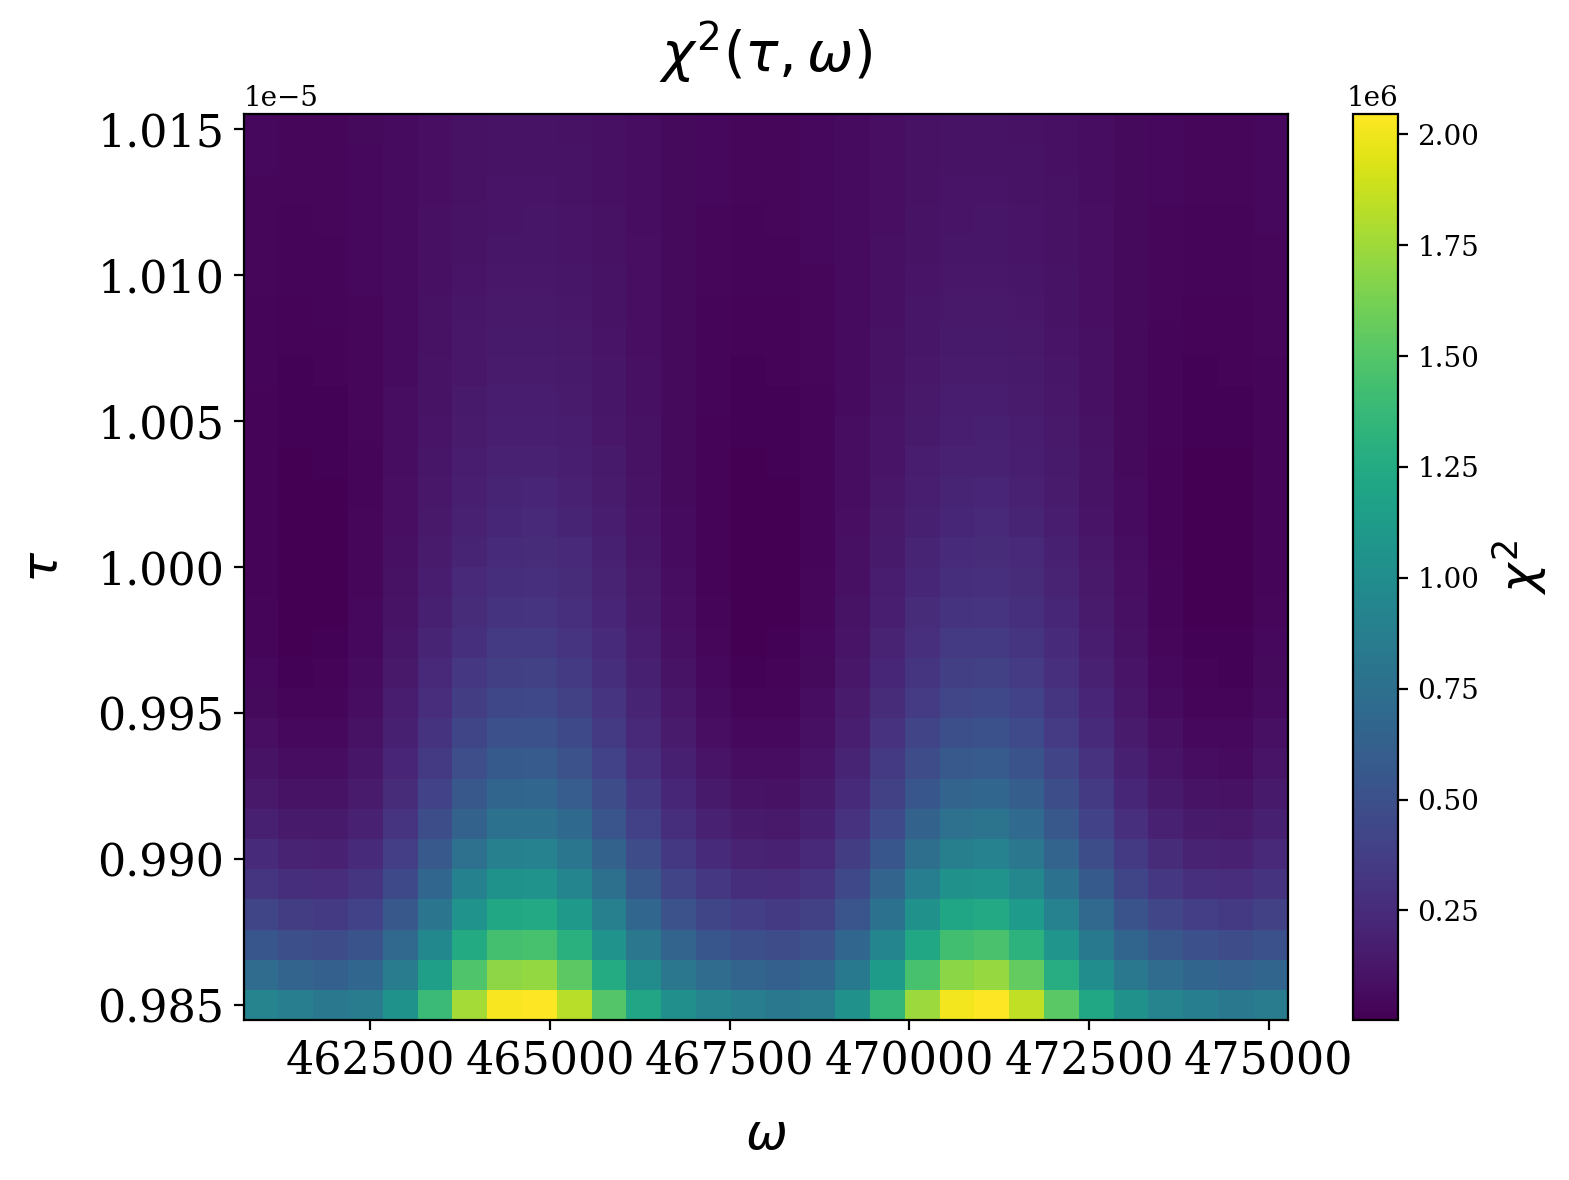

In [472]:
fig, ax = plt.subplots()
gf.parametri_grafico(ax,r"$\chi^2 ( \tau,\omega )$",xlabel=r"$\omega$",ylabel=r"$\tau$")

colore = ax.pcolormesh(O, T, chi_quadri, shading='auto', cmap='viridis')

fig.colorbar(colore, ax=ax, label=r"$\chi^2$")

gf.salva_grafico(fig,"chi_2d.pdf")